importing libraries

In [1]:
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import load_model
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

## Load the CSV and inspect

In [2]:
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [7]:
print("TotalCharges data type:", df["TotalCharges"].dtype)

blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print("Blank TotalCharges entries:", blank_total_charges)

TotalCharges data type: object
Blank TotalCharges entries: 11


In [8]:
#convert to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges values after conversion:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges values after conversion:
11


In [9]:
df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [10]:
#
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Shape after cleaning: (7032, 21)
Remaining missing values: 0


TotalCharges was stored as an object column because some rows contained blank
strings. I converted it to numeric using pd.to_numeric(errors="coerce"),
which changed blank values into NaN. Because only a small number of rows were
affected, I removed those rows.

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print("Unique customer IDs:", df["customerID"].nunique())
print("Number of rows:", len(df))

Unique customer IDs: 7032
Number of rows: 7032


# Examine churn balance

In [13]:

churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True).mul(100)

class_balance = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

class_balance

,Count,Percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


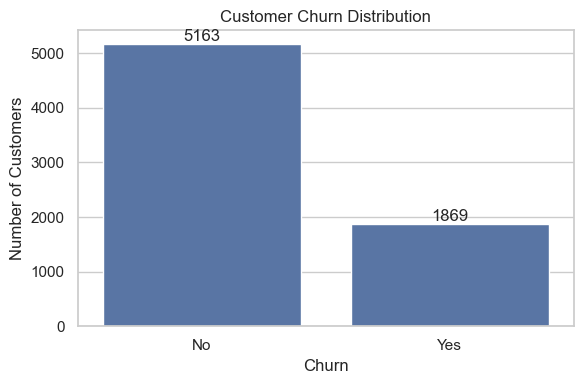

In [14]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The target is moderately imbalanced. The dataset contains substantially more
customers who did not churn than customers who churned. Therefore, accuracy
should not be used as the only evaluation metric.

# Churn versus contract type

In [15]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


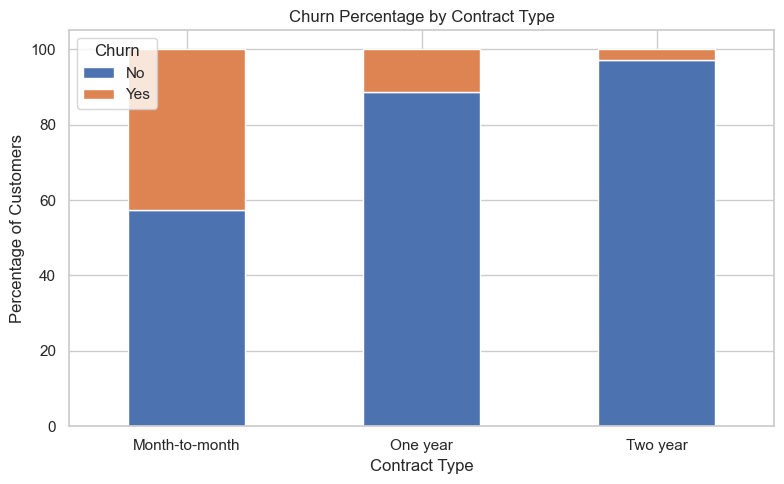

In [16]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

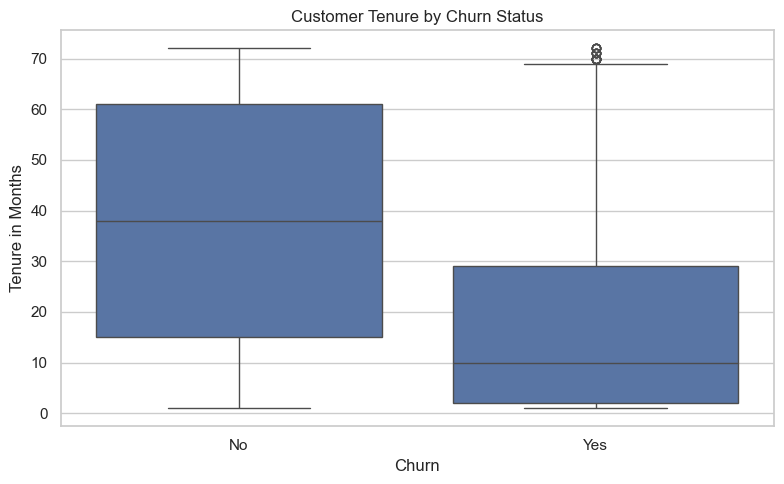

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")
plt.tight_layout()
plt.show()

 Customers with month-to-month contracts show a higher churn proportion thancustomers with one-year or two-year contracts. The tenure plot also suggeststhat customers who churn generally have shorter relationships with the company.

# Separate features and target

In [18]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Feature shape: (7032, 19)
Target shape: (7032,)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (5625, 19)
Test shape: (1407, 19)


In [20]:
numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# Create the preprocessing transformer

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ]
)

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (5625, 45)
Processed test shape: (1407, 45)


In [23]:
X_train_processed = X_train_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")

y_train_array = y_train.to_numpy().astype("float32")
y_test_array = y_test.to_numpy().astype("float32")

I used one-hot encoding for categorical variables such as Contract because
their categories do not have a natural numerical order. Assigning values such
as 0, 1, and 2 could incorrectly imply that one contract category is greater
than another. One-hot encoding avoids this artificial ordering.

# Build and train a baseline model

In [24]:
input_dimension = X_train_processed.shape[1]

baseline_model = Sequential([
    Input(shape=(input_dimension,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

Why these choices:

-relu is commonly used in hidden layers.

-sigmoid outputs a probability between 0 and 1.

-binary_crossentropy is appropriate for binary classification.

In [25]:
baseline_history = baseline_model.fit(
    X_train_processed,
    y_train_array,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7760 - loss: 0.4644 - val_accuracy: 0.8044 - val_loss: 0.4043
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8033 - loss: 0.4218 - val_accuracy: 0.8044 - val_loss: 0.4010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8058 - loss: 0.4162 - val_accuracy: 0.8071 - val_loss: 0.4017
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8089 - loss: 0.4123 - val_accuracy: 0.8080 - val_loss: 0.4023
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8093 - loss: 0.4091 - val_accuracy: 0.8089 - val_loss: 0.4036
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8107 - loss: 0.4064 - val_accuracy: 0.8098 - val_loss: 0.4049
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - loss: 0.4036 - val_accuracy: 0.8053 - val_loss: 0.4070
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8133 - loss: 0.4009 - val_accuracy: 0.

In [26]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test_processed,
    y_test_array,
    verbose=0
)

print(f"Baseline test loss: {baseline_loss:.4f}")
print(f"Baseline test accuracy: {baseline_accuracy:.4f}")

Baseline test loss: 0.5145
Baseline test accuracy: 0.7647


# Plot training and validation loss

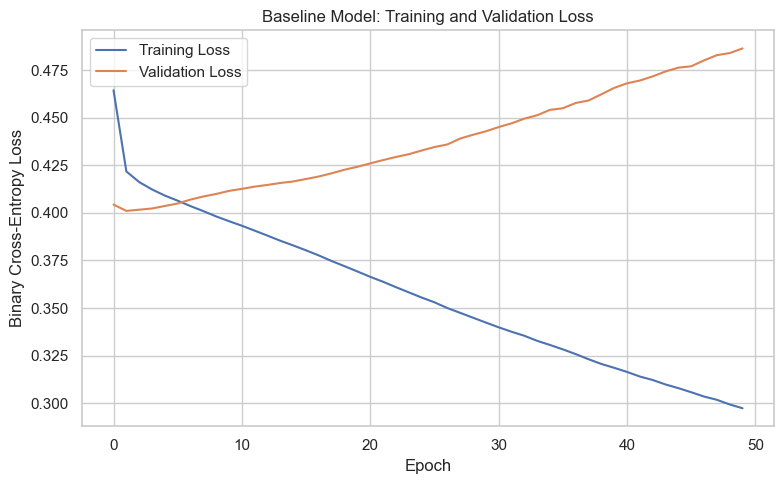

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline Model: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

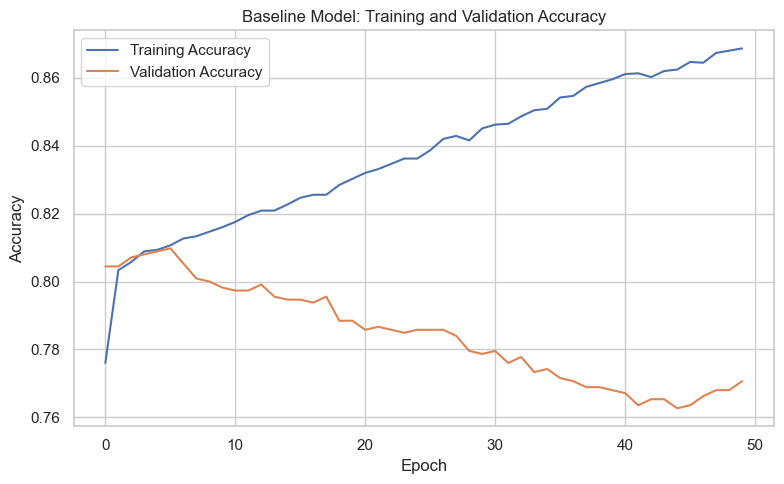

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline Model: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Tune the model

In [29]:
tuned_model = Sequential([
    Input(shape=(input_dimension,)),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.30),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.25),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.15),

    Dense(1, activation="sigmoid")
])

tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [30]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

 # Train the tuned model

In [31]:
tuned_history = tuned_model.fit(
    X_train_processed,
    y_train_array,
    validation_split=0.20,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7307 - loss: 0.7187 - val_accuracy: 0.7867 - val_loss: 0.6575
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7842 - loss: 0.6334 - val_accuracy: 0.7920 - val_loss: 0.6043
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7840 - loss: 0.6156 - val_accuracy: 0.7902 - val_loss: 0.5826
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7980 - loss: 0.5856 - val_accuracy: 0.7920 - val_loss: 0.5699
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8024 - loss: 0.5737 - val_accuracy: 0.7876 - val_loss: 0.5602
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8033 - loss: 0.5580 - val_accuracy: 0.7929 - val_loss: 0.5449
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.5565 - val_accuracy: 0.7929 - val_loss: 0.5393
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8044 - loss: 0.5411 - val_accu

In [32]:
tuned_loss, tuned_accuracy = tuned_model.evaluate(
    X_test_processed,
    y_test_array,
    verbose=0
)

print(f"Tuned test loss: {tuned_loss:.4f}")
print(f"Tuned test accuracy: {tuned_accuracy:.4f}")

Tuned test loss: 0.5040
Tuned test accuracy: 0.7896


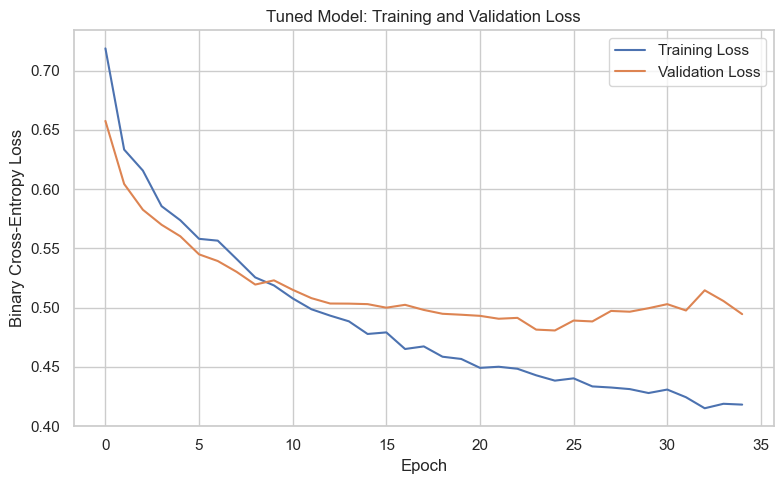

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    tuned_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    tuned_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Tuned Model: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

 # Before-and-after comparison

In [34]:
comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Tuned Model"],
    "Test Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ],
    "Test Loss": [
        baseline_loss,
        tuned_loss
    ]
})

comparison

,Model,Test Accuracy,Test Loss
0,Baseline Model,0.764748,0.514515
1,Tuned Model,0.789623,0.503953


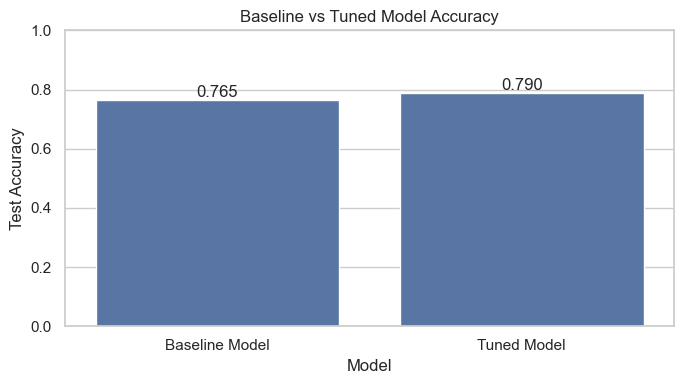

In [35]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=comparison,
    x="Model",
    y="Test Accuracy"
)

plt.title("Baseline vs Tuned Model Accuracy")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

# Evaluate the best model properly

In [36]:
if tuned_accuracy >= baseline_accuracy:
    best_model = tuned_model
    best_model_name = "Tuned Model"
else:
    best_model = baseline_model
    best_model_name = "Baseline Model"

print("Selected best model:", best_model_name)

Selected best model: Tuned Model


# Generate probabilities and class predictions

In [37]:
y_probability = best_model.predict(
    X_test_processed,
    verbose=0
).ravel()

y_pred = (y_probability >= 0.50).astype(int)

print("First 10 predicted probabilities:")
print(y_probability[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

First 10 predicted probabilities:
[0.00195047 0.7175245  0.00156166 0.17278795 0.22003865 0.39288086
 0.06114299 0.18222581 0.65102255 0.00087262]

First 10 predicted classes:
[0 1 0 0 0 0 0 0 1 0]


# Calculate evaluation metrics

In [38]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

metrics_table

,Metric,Score
0,Accuracy,0.789623
1,Precision,0.617470
2,Recall,0.548128
3,F1-score,0.580737


 # Classification report

In [39]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



# Confusion matrix

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[906, 127],
       [169, 205]])

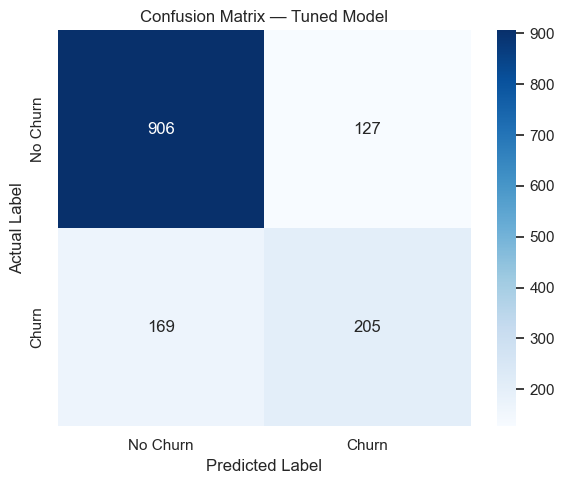

In [41]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [42]:
tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

True negatives: 906
False positives: 127
False negatives: 169
True positives: 205


In [43]:
# Accuracy alone can be misleading because the dataset contains more non-churn
#customers than churn customers. A model could obtain a relatively high accuracy
#by favoring the majority class while still failing to identify many customers
#who actually churn, so recall and F1-score are also important.

# Save the model and preprocessor

In [44]:
best_model.save("customer_churn_model.keras")

joblib.dump(
    preprocessor,
    "customer_churn_preprocessor.joblib"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [45]:
from pathlib import Path

print(
    Path("customer_churn_model.keras").exists()
)

print(
    Path("customer_churn_preprocessor.joblib").exists()
)

True
True


In [46]:
# Create a hypothetical customer

In [47]:
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 4,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.50,
    "TotalCharges": 382.00
}])

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,4,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.5,382.0


In [48]:
# Function that loads and uses the saved files

In [49]:
def predict_customer_churn(
    customer_data,
    model_path="customer_churn_model.keras",
    preprocessor_path="customer_churn_preprocessor.joblib",
    threshold=0.50
):
    """
    Load the saved preprocessing pipeline and Keras model,
    then predict customer churn.

    Parameters
    ----------
    customer_data : pandas.DataFrame
        One or more customers using the original feature columns.
    model_path : str
        Path to the saved Keras model.
    preprocessor_path : str
        Path to the saved sklearn preprocessor.
    threshold : float
        Probability threshold used to classify churn.

    Returns
    -------
    pandas.DataFrame
        Predicted churn class and probability.
    """
    if not isinstance(customer_data, pd.DataFrame):
        raise TypeError(
            "customer_data must be a pandas DataFrame."
        )

    loaded_preprocessor = joblib.load(
        preprocessor_path
    )

    loaded_model = load_model(
        model_path
    )

    processed_data = loaded_preprocessor.transform(
        customer_data
    ).astype("float32")

    churn_probabilities = loaded_model.predict(
        processed_data,
        verbose=0
    ).ravel()

    churn_predictions = (
        churn_probabilities >= threshold
    ).astype(int)

    results = pd.DataFrame({
        "Churn Probability": churn_probabilities,
        "Predicted Class": churn_predictions,
        "Prediction": np.where(
            churn_predictions == 1,
            "Yes",
            "No"
        )
    })

    return results

In [50]:
prediction_result = predict_customer_churn(
    new_customer
)

prediction_result

,Churn Probability,Predicted Class,Prediction
0,0.784235,1,Yes


In [51]:
probability = prediction_result.loc[
    0,
    "Churn Probability"
]

prediction = prediction_result.loc[
    0,
    "Prediction"
]

print(f"Predicted churn: {prediction}")
print(f"Churn probability: {probability:.2%}")

Predicted churn: Yes
Churn probability: 78.42%


# CNN versus RNN

A CNN is preferable to a Dense network when the input contains meaningful
spatial or local patterns, because convolutional filters can detect features
such as edges, shapes, and textures. For example, a CNN can be used to classify
images of cats and dogs. An RNN is preferable when the order of observations is
important and the data forms a sequence, such as text, speech, or time-series
measurements. For example, an RNN can be used to predict the next word in a
sentence or analyze sentiment in a sequence of words.